# Long Data 만들기
- 각 변수는 하나의 컬럼에 배치
- 각 관측치는 한행에 1건씩 분리되어 배치
- 각 값은 개별 셀에 배치

- melt()
- pivot()
- pivot_table() : 집계 함수를 적용 

In [1]:
import pandas as pd
import numpy as np

In [ ]:
src_file = r"D:\Practice\hipython\data\pew.csv"
df = pd.read_csv(src_file)

df.info()
df.describe()
df
df.info()
df.describe()
df

In [ ]:
df_melt = df.melt(id_vars=['religion'], var_name = 'income', value_name = 'count').sort_values('religion')
print(df_melt.head(20))
print(df_melt.columns)
df_melt['religion']
df_melt[df_melt['religion']=='Agnostic']

# df_melt = df_melt.rename(columns={"variable":"income", "value":"count"})

df_melt

In [ ]:
# Pivot

df_pivot = df_melt.pivot(  #long data > wide data
    index='religion',
    columns='income',
    values='count'
).reset_index()

df_pivot

In [ ]:
df_pivot = df_melt.pivot_table(  #long data > wide data
    index='religion',
    columns='income',
    values='count',
    aggfunc='sum'
)

df_pivot

In [ ]:
billboard_file = r"D:\Practice\hipython\data\billboard.csv"
df = pd.read_csv(billboard_file)

In [ ]:
# df_melt = df.melt(id_vars=df.columns[0:5], value_vars= df.columns[5:], var_name = 'week', value_name = 'rank').sort_values(['artist', 'date.entered', 'week'], ascending=[True, True, True])

df_melt = df.melt(id_vars=df.columns[0:5], var_name = 'week', value_name = 'rank')
# df_melt = df.melt(id_vars=df.columns[0:5], value_vars= df.columns[5:], var_name = 'week', value_name = 'rank')
# 순위는 정수로 변환
df_melt['rank'] = df_melt['rank'].astype('Int64')
df_melt['week'] = [week if len(week) == 4 else ("wk0"+week[-1]) for week in df_melt['week']]
df_melt = df_melt.sort_values(['artist', 'date.entered', 'week'], ascending=[True, True, True])

df_melt = df_melt.dropna()

df_melt

In [ ]:
import openpyxl

dest_file = r"D:\Practice\hipython\data\billboard_out.xlsx"
df_melt.to_excel(dest_file, index=False)

In [ ]:
df_pivot = df_melt.pivot_table(  #long data > wide data
    index='track',
    # index = df_melt.columns[0:5],
    columns=['week'],
    # columns=['year', 'artist', 'time', 'date.entered', 'week'],
    values='rank',
    # aggfunc='sum'
)
#).reset_index()

df_pivot.head(20)

In [ ]:
# 매출 데이터
sales_data = pd.DataFrame({
    'CustomerID': [101, 102, 103, 104],
    'Date': ['2023-01-01', '2023-01-03', '2023-01-05', '2023-01-07'],
    'Amount': [250, 300, 150, 400]
})

# 고객 데이터
customer_data = pd.DataFrame({
    'CustomerID': [101, 102, 103, 105],
    'Name': ['Alice', 'Bob', 'Charlie', 'Eva'],
    'Region': ['North', 'South', 'East', 'West']
})


In [ ]:
sales_data.info()

In [ ]:
customer_data.info()

# merge 
- left_data, right_data
- how = left/right/inner/outer
- on = 'Key Column'

In [ ]:
merged = pd.merge(customer_data, sales_data, on='CustomerID')
merged

print(pd.merge(customer_data, sales_data, how = 'left', on='CustomerID'))
print('-'*50)
print(pd.merge(customer_data, sales_data, how = 'right', on='CustomerID'))
print('-'*50)
print(pd.merge(customer_data, sales_data, how = 'outer', on='CustomerID'))

# Group By

In [ ]:
gapminder_file = r"D:\Practice\hipython\data\gapminder.tsv"
gap_df = pd.read_csv(gapminder_file, delimiter='\t')
gap_df.head()

In [ ]:
print(gap_df['country'].unique().shape) # 나라의 숫자
print(gap_df['continent'].unique().shape) # 나라의 숫자
print(gap_df['year'].unique().shape) # 나라의 숫자

In [ ]:
gp_country = gap_df.groupby(by='country')[['lifeExp', 'pop', 'gdpPercap']] ;
gp_country.mean() 
# gap_df.groupby(by='country')[['lifeExp', 'pop', 'gdpPercap']].sum()
# print(gap_df.groupby(by='country')[['lifeExp', 'pop', 'gdpPercap']].mean())
# gap_df.groupby(by='country')[['lifeExp', 'pop', 'gdpPercap']].median()
# gap_df.groupby(by='country')[['lifeExp', 'pop', 'gdpPercap']].var() # std/var
# gap_df.groupby(by='country')[['lifeExp', 'pop', 'gdpPercap']].std()
# gap_df.groupby(by='country')[['lifeExp', 'pop', 'gdpPercap']].size()  

In [ ]:
gap_df.groupby(by='year')[['lifeExp', 'pop', 'gdpPercap']].sum()
print(gap_df.groupby(by='year')[['lifeExp', 'pop', 'gdpPercap']].mean())
gap_df.groupby(by='year')[['lifeExp', 'pop', 'gdpPercap']].median()
gap_df.groupby(by='year')[['lifeExp', 'pop', 'gdpPercap']].var() # std/var
gap_df.groupby(by='year')[['lifeExp', 'pop', 'gdpPercap']].std()
# gap_df.groupby(by='year')[['lifeExp', 'pop', 'gdpPercap']].size()  

In [66]:
vehicle_file = r"D:\Practice\hipython\data\vehicle_prod.csv"
vehicle_df = pd.read_csv(vehicle_file, delimiter=',')

vehicle_df.rename(columns={'Unnamed: 0': 'country'}, inplace=True)

vehicle_df.set_index('country', inplace=True) # NOT vehicle_df.set_index(vehicle_df['country'], inplace=True)

vehicle_df.head()

,2007,2008,2009,2010,2011
country,,,,,
China,7.71,7.95,11.96,15.84,16.33
EU,19.02,17.71,15.00,16.70,17.48
US,10.47,8.45,5.58,7.60,8.40
Japan,10.87,10.83,7.55,9.09,7.88
Korea,4.04,3.78,3.45,4.20,4.62


In [67]:
# vehicle_df[['2008']]
vehicle_df.corr()

,2007,2008,2009,2010,2011
2007,1.000000,0.991073,0.831447,0.769040,0.758271
2008,0.991073,1.000000,0.872296,0.810529,0.789512
2009,0.831447,0.872296,1.000000,0.988513,0.980025
2010,0.769040,0.810529,0.988513,1.000000,0.992667
2011,0.758271,0.789512,0.980025,0.992667,1.000000


In [68]:
vehicle_df['Total Prod'] = vehicle_df.sum(axis=1)
vehicle_df.loc['Total'] = vehicle_df.sum(axis=0)

vehicle_df


,2007,2008,2009,2010,2011,Total Prod
country,,,,,,
China,7.71,7.95,11.96,15.84,16.33,59.79
EU,19.02,17.71,15.00,16.70,17.48,85.91
US,10.47,8.45,5.58,7.60,8.40,40.50
Japan,10.87,10.83,7.55,9.09,7.88,46.22
Korea,4.04,3.78,3.45,4.20,4.62,20.09
Mexico,2.01,2.05,1.50,2.25,2.54,10.35
Total,54.12,50.77,45.04,55.68,57.25,262.86


# 결측치 처리

In [108]:
pd.NA, np.nan  # 결측치

data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'age': [25, np.nan, 30, 22, np.nan],
    'score': [90, 85, np.nan, 88, 95],
    'city': ['Seoul', 'Busan', np.nan, 'Incheon', 'Seoul']
}

df = pd.DataFrame(data)
df.info()
df.dropna()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    5 non-null      object 
 1   age     3 non-null      float64
 2   score   4 non-null      float64
 3   city    4 non-null      object 
dtypes: float64(2), object(2)
memory usage: 288.0+ bytes


,name,age,score,city
0,Alice,25.0,90.0,Seoul
1,Bob,NaN,85.0,Busan
2,Charlie,30.0,NaN,NaN
3,David,22.0,88.0,Incheon
4,Eva,NaN,95.0,Seoul


- 0 또는 공백으로 채우기

In [ ]:
# df.fillna({'age':0, 'score':0, 'city':''}, inplace=True)
# df.fillna({'age':round(df['age'].mean()), 'score':0, 'city':''}, inplace=True)
df = df.fillna({'age':round(df['age'].mean()), 'city':'Unknown'})
df['score'] = df['score'].bfill() 

df

,name,age,score,city
0,Alice,25.0,90.0,Seoul
1,Bob,26.0,85.0,Busan
2,Charlie,30.0,88.0,Unknown
3,David,22.0,88.0,Incheon
4,Eva,26.0,95.0,Seoul


In [2]:
titanic_file = r"D:\Practice\hipython\data\titanic.csv"
titanic_df = pd.read_csv(titanic_file, delimiter=',')

# vehicle_df.rename(columns={'Unnamed: 0': 'country'}, inplace=True)

# vehicle_df.set_index('country', inplace=True) # NOT vehicle_df.set_index(vehicle_df['country'], inplace=True)

titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [116]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic_df['Age'].mean()

np.float64(29.69911764705882)

In [4]:
titanic_df = titanic_df.fillna({'Age': titanic_df['Age'].median()})

<Axes: ylabel='Frequency'>

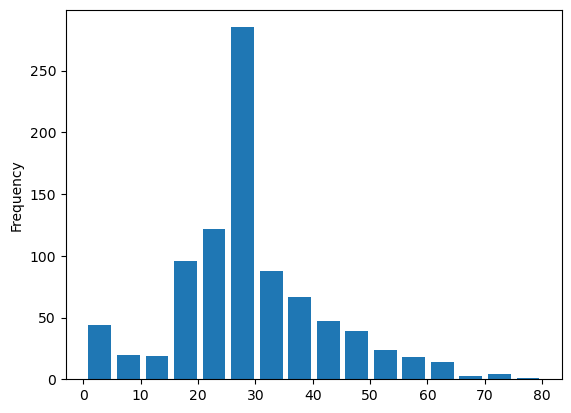

In [7]:
titanic_df['Age'].plot(kind='hist', bins=16, rwidth = 0.8)

In [12]:
titanic_df = titanic_df.fillna({'Cabin': 'Unknown'})
titanic_df['Cabin'].unique()
titanic_df['Cabin'].value_counts().tail(20)

Cabin
C46        1
D30        1
D11        1
D49        1
E77        1
F38        1
D6         1
B3         1
B82 B84    1
A36        1
B102       1
B69        1
E49        1
C47        1
D28        1
E17        1
A24        1
C50        1
B42        1
C148       1
Name: count, dtype: int64

In [25]:
titanic_df.groupby('Cabin')[['Fare', 'Survived']].mean()

titanic_df['Cabin.Cat'] = [cat[0] for cat in titanic_df['Cabin']]

print(titanic_df.groupby('Cabin.Cat')[['Fare', 'Survived']].mean())


print(titanic_df.groupby('Sex')['PassengerId'].count())
titanic_df.groupby('Sex')[['Fare', 'Survived']].mean()


                 Fare  Survived
Cabin.Cat                      
A           39.623887  0.466667
B          113.505764  0.744681
C          100.151341  0.593220
D           57.244576  0.757576
E           46.026694  0.750000
F           18.696792  0.615385
G           13.581250  0.500000
T           35.500000  0.000000
U           19.157325  0.299854
Sex
female    314
male      577
Name: PassengerId, dtype: int64


,Fare,Survived
Sex,,
female,44.479818,0.742038
male,25.523893,0.188908


# One-Hot Encoding & Label Encoding

In [43]:
titanic_df['Sex'].map({'male':0, 'female':1})

pd.get_dummies(titanic_df, columns=['Sex', 'Embarked'])

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Cabin.Cat,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,U,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,U,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,C,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,U,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,Unknown,U,False,True,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,B,True,False,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,W./C. 6607,23.4500,Unknown,U,True,False,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,False,True,True,False,False


In [31]:
sex_df = titanic_df.groupby('Sex')

sex_count = sex_df['PassengerId'].count()
sex_means = sex_df[['Fare', 'Survived']].mean()

type(sex_count), type(sex_means)
sex_count.index, sex_means.index

(Index(['female', 'male'], dtype='object', name='Sex'),
 Index(['female', 'male'], dtype='object', name='Sex'))

In [41]:
sex_count.info()
sex_count.name = 'count'
sex_means[sex_count.name] = sex_count

sex_means

<class 'pandas.core.series.Series'>
Index: 2 entries, female to male
Series name: count
Non-Null Count  Dtype
--------------  -----
2 non-null      int64
dtypes: int64(1)
memory usage: 140.0+ bytes


,Fare,Survived,count
Sex,,,
female,44.479818,0.742038,314
male,25.523893,0.188908,577
